# Data-center pipeline pressure on state electricity systems

This notebook tests whether reported data-center projects are large relative to each state's existing electricity system. The central metric is:

**reported pipeline MW / 2024 average generation MW**

The comparison is a screening indicator—not a forecast of load, peak-capacity requirement, reserve margin, or reliability.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

# Work whether the notebook is launched from the repository root or Script/.
cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'Data').exists() else cwd.parent
DATA = ROOT / 'Data'
OUTPUT = ROOT / 'analysis_outputs'
FIGURE_OUTPUT = ROOT / 'Script' / 'notebook_assets'
OUTPUT.mkdir(exist_ok=True)
FIGURE_OUTPUT.mkdir(exist_ok=True)
ROOT

PosixPath('/Users/annagrace/Desktop/School/Drexel/Summer 2026/DSCI591')

## 1. Load and prepare the data

Pipeline projects are those marked **Proposed**, **Approved/Permitted/Under construction**, or **Expanding**. Text MW fields are converted using their first numeric value; for a range, this uses the lower endpoint.

In [2]:
electricity = pd.read_csv(DATA / 'Electricity' / 'ELEC.state_year.csv')
centers = pd.read_csv(DATA / 'Data_Centers_Database - FracTracker Data Centers.csv')
centers.columns = centers.columns.str.strip().str.lower()
centers['state'] = centers['state'].astype('string').str.strip().str.upper()
centers['status'] = centers['status'].astype('string').str.strip()

def first_number(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'[-+]?\d*\.?\d+', str(value).replace(',', ''))
    return float(match.group()) if match else np.nan

pipeline_statuses = {
    'Proposed',
    'Approved/Permitted/Under construction',
    'Expanding',
}
centers['reported_mw'] = centers['mw'].map(first_number)
centers['is_pipeline'] = centers['status'].isin(pipeline_statuses)
# Conservative flag: require an explicit dedicated plant ('Yes...') or a
# power-source description that explicitly says onsite/hybrid. Backup-only
# generator records are not treated as normal onsite generation.
centers['explicit_onsite_or_hybrid'] = (
    centers['dedicated_power_plant'].fillna('').str.strip().str.lower().str.startswith('yes')
    | centers['power_source'].fillna('').str.contains(
        'Hybrid (onsite and grid)', regex=False
    )
)
pipeline = centers.loc[centers['is_pipeline']].copy()
pipeline['reported_onsite_mw'] = pipeline['reported_mw'].where(
    pipeline['explicit_onsite_or_hybrid'], 0
)
pipeline['reported_no_onsite_evidence_mw'] = pipeline['reported_mw'].where(
    ~pipeline['explicit_onsite_or_hybrid'], 0
)

print(f'Data-center records: {len(centers):,}')
print(f'Pipeline records: {len(pipeline):,}')
print(f'Pipeline records with MW: {pipeline.reported_mw.notna().sum():,} '
      f'({pipeline.reported_mw.notna().mean():.1%})')
print(f'Pipeline projects with explicit dedicated/hybrid generation: '
      f'{pipeline.explicit_onsite_or_hybrid.sum():,}')

Data-center records: 1,592
Pipeline records: 943
Pipeline records with MW: 355 (37.6%)
Pipeline projects with explicit dedicated/hybrid generation: 29


## 2. Construct the grid-pressure indicator

2024 is used because the 2025 generation data appear incomplete for some states. Annual MWh are divided by 8,760 hours to obtain average generation MW.

In [3]:
pipeline_by_state = (
    pipeline.groupby('state')
    .agg(
        pipeline_projects=('facility_name', 'size'),
        projects_reporting_mw=('reported_mw', 'count'),
        reported_pipeline_mw=('reported_mw', 'sum'),
        explicit_onsite_projects=('explicit_onsite_or_hybrid', 'sum'),
        reported_onsite_mw=('reported_onsite_mw', 'sum'),
        reported_no_onsite_evidence_mw=('reported_no_onsite_evidence_mw', 'sum'),
    )
)

generation_2024 = (
    electricity.loc[electricity['year'].eq(2024), ['state', 'generation_mwh']]
    .set_index('state')['generation_mwh']
    .rename('generation_mwh_2024')
)

pressure = pipeline_by_state.join(generation_2024, how='inner')
pressure['average_generation_mw_2024'] = pressure['generation_mwh_2024'] / 8_760
pressure['pipeline_share_of_average_generation_pct'] = (
    100 * pressure['reported_pipeline_mw'] / pressure['average_generation_mw_2024']
)
pressure['reported_onsite_share_of_generation_pct'] = (
    100 * pressure['reported_onsite_mw'] / pressure['average_generation_mw_2024']
)
pressure['reported_no_onsite_share_of_generation_pct'] = (
    100 * pressure['reported_no_onsite_evidence_mw'] / pressure['average_generation_mw_2024']
)
pressure['mw_reporting_rate_pct'] = (
    100 * pressure['projects_reporting_mw'] / pressure['pipeline_projects']
)

# Limit the headline comparison to states with sizable pipelines to reduce
# instability caused by one or two unusually large proposed projects.
headline = (
    pressure.loc[pressure['pipeline_projects'].ge(10)]
    .sort_values('pipeline_share_of_average_generation_pct', ascending=False)
)

display_cols = [
    'pipeline_projects', 'projects_reporting_mw', 'explicit_onsite_projects',
    'reported_pipeline_mw', 'reported_onsite_mw',
    'average_generation_mw_2024',
    'pipeline_share_of_average_generation_pct', 'mw_reporting_rate_pct'
]
headline[display_cols].head(12)

,pipeline_projects,projects_reporting_mw,explicit_onsite_projects,reported_pipeline_mw,reported_onsite_mw,average_generation_mw_2024,pipeline_share_of_average_generation_pct,mw_reporting_rate_pct
state,,,,,,,,
UT,10,7,1,"13,225.0","1,500.0","3,599.1",367.4,70.0
WV,12,7,4,"9,353.0","8,453.0","5,775.7",161.9,58.3
OH,43,18,8,"15,635.0","11,491.0","14,795.1",105.7,41.9
NV,13,10,1,"5,302.0",170.0,"5,175.3",102.4,76.9
VA,263,25,0,"10,971.0",0.0,"11,721.8",93.6,9.5
IN,24,8,0,"9,733.0",0.0,"10,552.2",92.2,33.3
TX,137,74,1,"52,791.0",300.0,"64,363.2",82.0,54.0
GA,85,28,1,"11,307.0",500.0,"15,959.1",70.8,32.9
PA,51,19,6,"17,284.0","10,230.0","27,563.2",62.7,37.3


## 3. Main finding

Ohio's reported pipeline MW is larger than the state's entire 2024 average generation, but most of that reported capacity is associated with projects that explicitly identify dedicated or hybrid generation. The remaining blue portion is the more direct grid-exposure warning; blank power-source fields remain unknown rather than confirmed grid supply.

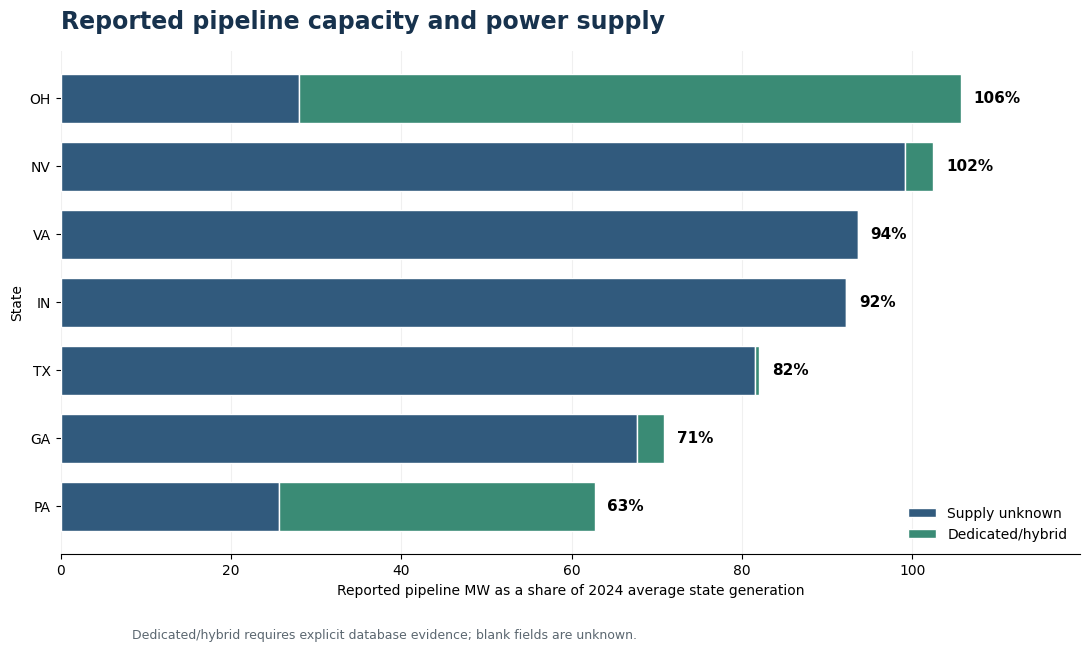

PosixPath('/Users/annagrace/Desktop/School/Drexel/Summer 2026/DSCI591/Script/notebook_assets/data_center_pipeline_grid_pressure.png')

In [9]:
focus_states = ['OH', 'NV', 'VA', 'IN', 'TX', 'GA', 'PA']
chart = pressure.loc[focus_states].sort_values(
    'pipeline_share_of_average_generation_pct', ascending=True
)

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(chart.index, chart['reported_no_onsite_share_of_generation_pct'],
               color='#315A7D', edgecolor='white', height=0.72,
               label='Supply unknown')
ax.barh(chart.index, chart['reported_onsite_share_of_generation_pct'],
        left=chart['reported_no_onsite_share_of_generation_pct'],
        color='#3A8B75', edgecolor='white', height=0.72,
        label='Dedicated/hybrid')

for bar, (state, row) in zip(bars, chart.iterrows()):
    value = row['pipeline_share_of_average_generation_pct']
    ax.text(value + 1.5, bar.get_y() + bar.get_height()/2, f'{value:.0f}%',
            va='center', fontweight='bold', fontsize=11)

ax.set_title('Reported pipeline capacity and power supply',
             loc='left', fontsize=17, fontweight='bold', color='#17324D', pad=16)
ax.set_xlabel('Reported pipeline MW as a share of 2024 average state generation')
ax.set_ylabel('State')
ax.set_xlim(0, max(115, chart['pipeline_share_of_average_generation_pct'].max() + 14))
ax.legend(frameon=False, loc='lower right')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.18)
ax.set_axisbelow(True)
fig.text(0.125, 0.01,
         'Dedicated/hybrid requires explicit database evidence; blank fields are unknown.',
         fontsize=9, color='#5B6770')
fig.tight_layout(rect=[0, 0.05, 1, 1])
chart_path = FIGURE_OUTPUT / 'data_center_pipeline_grid_pressure.png'
fig.savefig(chart_path, dpi=220, bbox_inches='tight')
plt.show()
chart_path

## 4. Estimate missing MW from facility square footage

Because both variables are highly skewed, the model uses $\log_{10}(MW)$ as the outcome and $\log_{10}(square\ feet)$ as the predictor. Ten-fold cross-validation measures performance on facilities excluded from model fitting. This avoids reporting in-sample fit as predictive accuracy.

The model intentionally excludes `sizerank`, because that category is defined using MW and would leak information about the target into the prediction.

In [5]:
centers['facility_sqft'] = centers['facility_size_sqft'].map(first_number)
training = centers.loc[
    centers['reported_mw'].gt(0) & centers['facility_sqft'].gt(0),
    ['reported_mw', 'facility_sqft']
].copy()

X = np.log10(training[['facility_sqft']])
y = np.log10(training['reported_mw'])
model = LinearRegression()
folds = KFold(n_splits=10, shuffle=True, random_state=591)
cv_log_prediction = cross_val_predict(model, X, y, cv=folds)
cv_mw_prediction = 10 ** cv_log_prediction
factor_error = np.maximum(
    cv_mw_prediction / training['reported_mw'].to_numpy(),
    training['reported_mw'].to_numpy() / cv_mw_prediction,
)

validation = pd.Series({
    'training_facilities': len(training),
    'cross_validated_log_R2': r2_score(y, cv_log_prediction),
    'cross_validated_MAE_MW': mean_absolute_error(training['reported_mw'], cv_mw_prediction),
    'cross_validated_median_absolute_error_MW': median_absolute_error(training['reported_mw'], cv_mw_prediction),
    'median_multiplicative_error': np.median(factor_error),
})
display(validation.to_frame('value'))

model.fit(X, y)
print(f'Fitted equation: log10(MW) = {model.intercept_:.3f} + '
      f'{model.coef_[0]:.3f} × log10(square feet)')

,value
training_facilities,349.0
cross_validated_log_R2,0.7
cross_validated_MAE_MW,192.2
cross_validated_median_absolute_error_MW,29.5
median_multiplicative_error,1.9


Fitted equation: log10(MW) = -3.372 + 0.932 × log10(square feet)


In [6]:
# Predict only where MW is missing and usable square footage is present.
needs_imputation = (
    centers['is_pipeline']
    & centers['reported_mw'].isna()
    & centers['facility_sqft'].gt(0)
    & ~centers['explicit_onsite_or_hybrid']
)
centers['estimated_mw_from_sqft'] = np.nan
centers.loc[needs_imputation, 'estimated_mw_from_sqft'] = 10 ** model.predict(
    np.log10(centers.loc[needs_imputation, ['facility_sqft']])
)

pipeline_modeled = centers.loc[centers['is_pipeline']].copy()
pipeline_modeled['reported_onsite_mw'] = pipeline_modeled['reported_mw'].where(
    pipeline_modeled['explicit_onsite_or_hybrid'], 0
)
pipeline_modeled['reported_no_onsite_evidence_mw'] = pipeline_modeled['reported_mw'].where(
    ~pipeline_modeled['explicit_onsite_or_hybrid'], 0
)
pipeline_modeled['estimated_onsite_mw'] = pipeline_modeled['estimated_mw_from_sqft'].where(
    pipeline_modeled['explicit_onsite_or_hybrid'], 0
)
pipeline_modeled['estimated_no_onsite_evidence_mw'] = pipeline_modeled['estimated_mw_from_sqft'].where(
    ~pipeline_modeled['explicit_onsite_or_hybrid'], 0
)
modeled_state = (
    pipeline_modeled.groupby('state')
    .agg(
        pipeline_projects=('facility_name', 'size'),
        projects_with_reported_mw=('reported_mw', 'count'),
        projects_with_imputed_mw=('estimated_mw_from_sqft', 'count'),
        reported_pipeline_mw=('reported_mw', 'sum'),
        imputed_pipeline_mw=('estimated_mw_from_sqft', 'sum'),
        explicit_onsite_projects=('explicit_onsite_or_hybrid', 'sum'),
        reported_onsite_mw=('reported_onsite_mw', 'sum'),
        reported_no_onsite_evidence_mw=('reported_no_onsite_evidence_mw', 'sum'),
        estimated_onsite_mw=('estimated_onsite_mw', 'sum'),
        estimated_no_onsite_evidence_mw=('estimated_no_onsite_evidence_mw', 'sum'),
    )
    .join(generation_2024, how='inner')
)
modeled_state['average_generation_mw_2024'] = modeled_state['generation_mwh_2024'] / 8_760
modeled_state['reported_share_pct'] = (
    100 * modeled_state['reported_pipeline_mw'] / modeled_state['average_generation_mw_2024']
)
modeled_state['imputed_share_pct'] = (
    100 * modeled_state['imputed_pipeline_mw'] / modeled_state['average_generation_mw_2024']
)
modeled_state['combined_share_pct'] = (
    modeled_state['reported_share_pct']
    + 100 * modeled_state['estimated_no_onsite_evidence_mw']
      / modeled_state['average_generation_mw_2024']
)
for source in [
    'reported_onsite_mw', 'reported_no_onsite_evidence_mw',
    'estimated_onsite_mw', 'estimated_no_onsite_evidence_mw'
]:
    modeled_state[source + '_share_pct'] = (
        100 * modeled_state[source] / modeled_state['average_generation_mw_2024']
    )
modeled_state['projects_still_missing_mw'] = (
    modeled_state['pipeline_projects']
    - modeled_state['projects_with_reported_mw']
    - modeled_state['projects_with_imputed_mw']
)

print(f"Pipeline projects with regression-imputed MW: {needs_imputation.sum():,}")
print(f"Pipeline projects not imputed (onsite flagged or square footage missing): "
      f"{len(pipeline_modeled) - pipeline_modeled.reported_mw.notna().sum() - needs_imputation.sum():,}")
modeled_state.reset_index().to_csv(
    OUTPUT / 'data_center_pipeline_pressure_regression_summary.csv', index=False
)
pipeline_modeled[[
    'facility_name', 'state', 'status', 'facility_sqft', 'reported_mw',
    'estimated_mw_from_sqft', 'explicit_onsite_or_hybrid',
    'dedicated_power_plant', 'power_source', 'number_of_generators'
]].to_csv(OUTPUT / 'data_center_pipeline_mw_imputed.csv', index=False)

modeled_state.loc[focus_states, [
    'pipeline_projects', 'projects_with_reported_mw', 'projects_with_imputed_mw',
    'projects_still_missing_mw', 'explicit_onsite_projects',
    'reported_share_pct', 'imputed_share_pct',
    'combined_share_pct'
]].sort_values('combined_share_pct', ascending=False)

Pipeline projects with regression-imputed MW: 364
Pipeline projects not imputed (onsite flagged or square footage missing): 224


,pipeline_projects,projects_with_reported_mw,projects_with_imputed_mw,projects_still_missing_mw,explicit_onsite_projects,reported_share_pct,imputed_share_pct,combined_share_pct
state,,,,,,,,
VA,263,25,196,42,0,93.6,378.1,471.7
GA,85,28,44,13,1,70.8,144.8,215.6
OH,43,18,7,18,8,105.7,3.3,108.9
NV,13,10,0,3,1,102.4,0.0,102.4
IN,24,8,6,10,0,92.2,7.1,99.4
TX,137,74,30,33,1,82.0,4.8,86.8
PA,51,19,21,11,6,62.7,14.0,76.7


## 5. Observed and regression-estimated pipeline pressure

Dark blue is all reported pipeline MW. Light blue is missing MW estimated from facility square footage. Facilities with explicit dedicated or hybrid generation are never regression-imputed.

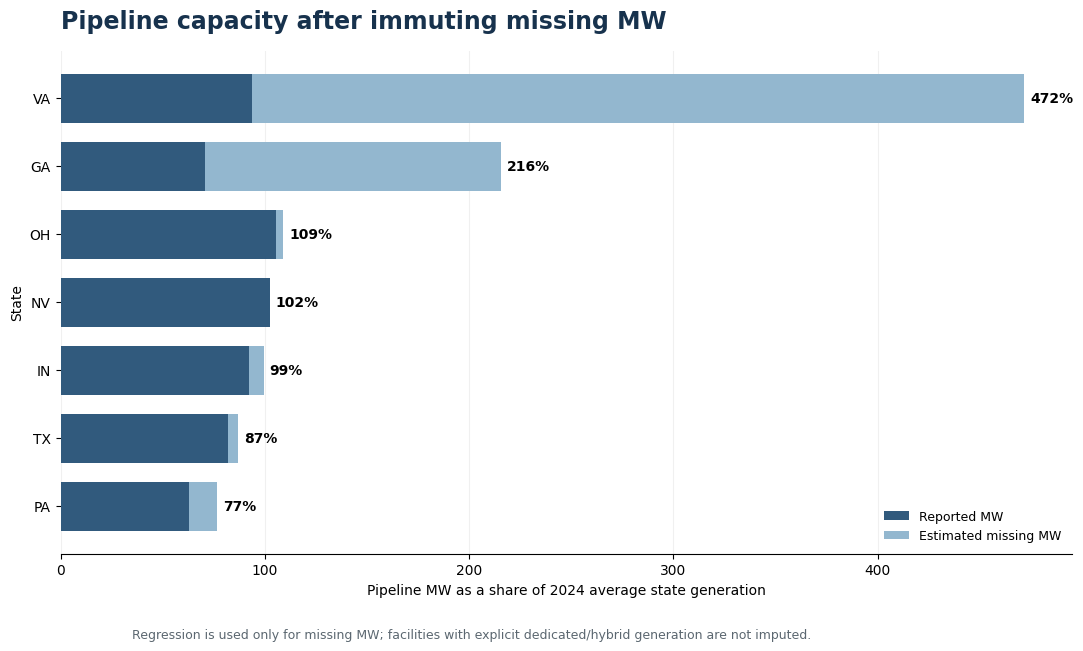

PosixPath('/Users/annagrace/Desktop/School/Drexel/Summer 2026/DSCI591/Script/notebook_assets/data_center_pipeline_pressure_with_regression.png')

In [10]:
modeled_chart = modeled_state.loc[focus_states].sort_values('combined_share_pct')
fig, ax = plt.subplots(figsize=(11, 6.5))
stack_specs = [
    ('reported_share_pct', '#315A7D', 'Reported MW'),
    ('estimated_no_onsite_evidence_mw_share_pct', '#93B7CF', 'Estimated missing MW'),
]
left = np.zeros(len(modeled_chart))
for column, color, label in stack_specs:
    values = modeled_chart[column].to_numpy()
    ax.barh(modeled_chart.index, values, left=left, color=color,
            height=0.72, label=label)
    left += values

for y_pos, (state, row) in enumerate(modeled_chart.iterrows()):
    ax.text(row['combined_share_pct'] + 3, y_pos, f"{row['combined_share_pct']:.0f}%",
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Pipeline capacity after immuting missing MW',
             loc='left', fontsize=17, fontweight='bold', color='#17324D', pad=16)
ax.set_xlabel('Pipeline MW as a share of 2024 average state generation')
ax.set_ylabel('State')
ax.legend(frameon=False, loc='lower right', fontsize=9)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.18)
ax.set_axisbelow(True)
fig.text(0.125, 0.01,
         'Regression is used only for missing MW; facilities with explicit dedicated/hybrid generation are not imputed.',
         fontsize=9, color='#5B6770')
fig.tight_layout(rect=[0, 0.05, 1, 1])
modeled_chart_path = FIGURE_OUTPUT / 'data_center_pipeline_pressure_with_regression.png'
fig.savefig(modeled_chart_path, dpi=220, bbox_inches='tight')
plt.show()
modeled_chart_path

In [8]:
oh = pressure.loc['OH']
oh_2015 = electricity.query("state == 'OH' and year == 2015").iloc[0]
oh_2024 = electricity.query("state == 'OH' and year == 2024").iloc[0]
oh_generation_growth = 100 * (oh_2024.generation_mwh / oh_2015.generation_mwh - 1)

print(
    f"OHIO FINDING\n"
    f"• {int(oh.pipeline_projects)} pipeline projects; "
    f"{int(oh.projects_reporting_mw)} report MW.\n"
    f"• Reported pipeline: {oh.reported_pipeline_mw:,.0f} MW.\n"
    f"• 2024 average generation: {oh.average_generation_mw_2024:,.0f} MW.\n"
    f"• Pipeline scale: {oh.pipeline_share_of_average_generation_pct:.1f}% "
    f"of average generation.\n"
    f"• Explicit dedicated/hybrid component: {oh.reported_onsite_mw:,.0f} MW; "
    f"no-explicit-onsite-evidence component: {oh.reported_no_onsite_evidence_mw:,.0f} MW.\n"
    f"• Ohio generation grew only {oh_generation_growth:.1f}% from 2015–2024."
)

pressure.reset_index().to_csv(OUTPUT / 'data_center_pipeline_grid_pressure.csv', index=False)

OHIO FINDING
• 43 pipeline projects; 18 report MW.
• Reported pipeline: 15,635 MW.
• 2024 average generation: 14,795 MW.
• Pipeline scale: 105.7% of average generation.
• Explicit dedicated/hybrid component: 11,491 MW; no-explicit-onsite-evidence component: 4,144 MW.
• Ohio generation grew only 11.4% from 2015–2024.


## Interpretation and limitations

A defensible headline is: **Ohio's reported data-center pipeline exceeds average state generation, but roughly three-quarters of the reported MW belongs to projects explicitly associated with dedicated or hybrid generation.**

Important qualifications:

- Proposed capacity may be cancelled, delayed, phased, or never fully utilized.
- Requested/nameplate MW is not the same as realized electricity consumption.
- Some projects may use dedicated generation or import power across state lines.
- Average generation is not peak demand, installed capacity, reserve margin, or locally deliverable capacity.
- MW reporting is incomplete, and text ranges are represented by their lower endpoint.
- State averages cannot reveal localized substation or transmission constraints.

The metric should therefore be described as a **grid-planning pressure indicator**, not proof of outages or a causal reliability effect.